# Extended Data Fig. 31 - Validation of age-dependent microglial redistribution using 2D physical serial sections

The age-dependent microglial redistribution (normalized delta-microglia ratio, 9m minus 1m) across the 8 practical gray-matter (pGM) to practical white-matter (pWM) masks (as in Fig. 5j,k) is compared between the 3D whole-brain reference and 20 physical serial sections (WT).

- ED31a: redistribution maps (Z-normalized) - 3D reference vs 20 physical sections.
- ED31b: correlation of the delta ratios across the 8 masks (Spearman Rs = 0.881, p < 0.01).
- ED31c: simulation (100 trials/step) of recovery vs the number of subsampled sections.

> Figures preserved from the original run; Japanese stripped; verbose logs removed.

## Input files

| File | Content |
|---|---|
| 3D whole-brain microglial ratio per pGM/pWM mask (1m, 9m) | 3D reference redistribution |
| 20 Iba1-stained physical serial sections, per pGM/pWM mask | 2D physical redistribution |
| 8 pGM/pWM masks | gray-to-white compartments |

## ED31a - Redistribution maps (Z-normalized): 3D reference vs 20 physical sections

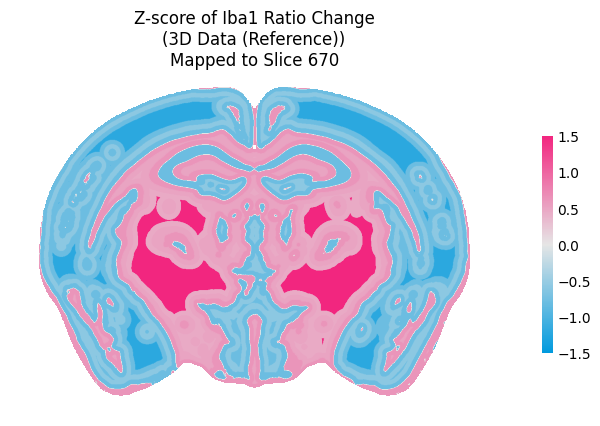

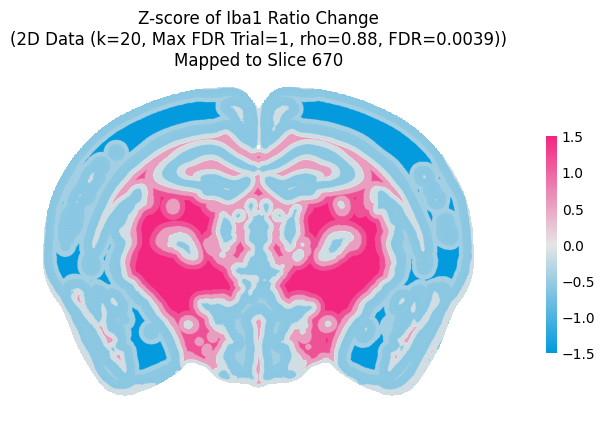

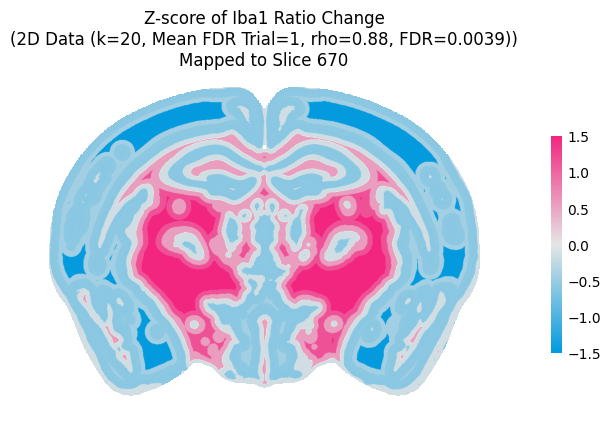

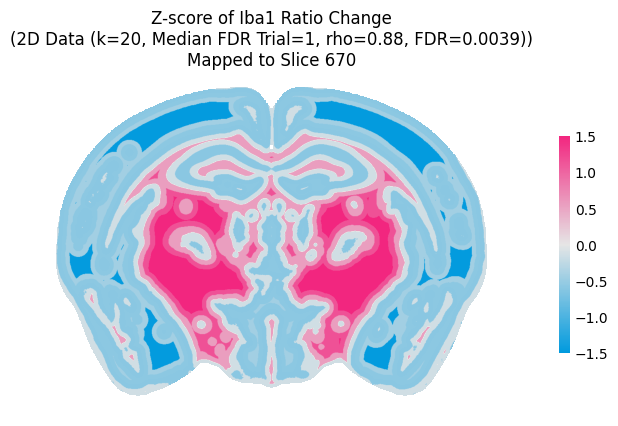

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import os
import tifffile #  TIFF 
import sys #   exit()  
from scipy.stats import spearmanr #   Spearman 
#
from statsmodels.stats.multitest import fdrcorrection

# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---

#
BASE_STARDIST_DIR = "/data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw/output_stardist"

#
REFERENCE_3D_CSV_PATH = "/data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw/output_stardist/Iba1_Ratio_Pivot_WT_1m_vs_9m.csv"

#
INPUT_CSV_1M = os.path.join(BASE_STARDIST_DIR, "Iba1_Ratio_Simulation_WT_1m.csv")
INPUT_CSV_9M = os.path.join(BASE_STARDIST_DIR, "Iba1_Ratio_Simulation_WT_9m.csv")

#
SLICE_NUM = 670
ATLAS_TIFF_PATH = f"/data4/Neurology_project_data_archive/Cellome/30_distance_map_using_0.43812782_Threshed_Mask_WM_and_GM_coronal_{SLICE_NUM}.tif"

#
#
NUM_TRIALS = 100 
#
K_VALUE_TO_CHECK = 20

#
Z_SCORE_COLOR_LIMIT = 1.5


# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---
#
#


# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---

print(f"===  1: 3D Pivot ( ) CSV  ===")
try:
    data_pivot_all_3d_raw = pd.read_csv(REFERENCE_3D_CSV_PATH, index_col='atlasID') / 1000
    data_pivot_3d = data_pivot_all_3d_raw[["WT_1m", "WT_9m"]]
    #
    df_3d_diff = (data_pivot_3d['WT_9m'] - data_pivot_3d['WT_1m']).fillna(0)
    print(f"  -> 3D  (9m - 1m)  :\n{df_3d_diff.head(8)}")
except Exception as e:
    print(f"!!!  : 3D CSV : {e}")
    sys.exit(" ")


print(f"\n===  2: 2D CSV (k={K_VALUE_TO_CHECK}  )   ===")
try:
    df_sim_1m_full = pd.read_csv(INPUT_CSV_1M)
    df_sim_9m_full = pd.read_csv(INPUT_CSV_9M)
    
    #
    df_sim_1m_k1 = df_sim_1m_full[df_sim_1m_full['k_slices'] == K_VALUE_TO_CHECK]
    df_sim_1m_indexed = df_sim_1m_k1.set_index(['trial_num', 'atlasID'])['Iba1_Ratio']

    #
    df_sim_9m_k1 = df_sim_9m_full[df_sim_9m_full['k_slices'] == K_VALUE_TO_CHECK]
    df_sim_9m_indexed = df_sim_9m_k1.set_index(['trial_num', 'atlasID'])['Iba1_Ratio']
    
    print(f"  -> 1m/9m CSV  (k={K_VALUE_TO_CHECK}  )  ")

except FileNotFoundError:
    print(f"!!!  :  CSV ")
    print(f"   : {INPUT_CSV_1M}   {INPUT_CSV_9M}")
    sys.exit(" ")
except Exception as e:
    print(f"!!!  : 2D CSV / : {e}")
    sys.exit(" ")

#
try:
    df_sim_diff_k1 = (df_sim_9m_indexed - df_sim_1m_indexed).fillna(0)
    print(f"  -> 2D  (k={K_VALUE_TO_CHECK})  ")
except Exception as e:
    print(f"!!!  : 2D : {e}")
    sys.exit(" ")


# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---

print(f"\n===  3:   (Slice {SLICE_NUM})   ===")
try:
    atlas_image = tifffile.imread(ATLAS_TIFF_PATH)
    print(f"  ->  : {atlas_image.shape},  : {np.unique(atlas_image)}")
except FileNotFoundError:
    print(f"!!!  :  \n     : {ATLAS_TIFF_PATH}")
    exit() 
except Exception as e:
    print(f"!!!  :  : {e}")
    exit()


# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---
#

def create_custom_cmap():
    """  - / 0 / +  """
    colors = [(0.0, 154/255, 222/255), (0.9, 0.9, 0.9), (0.95, 0.15, 0.5)] 
    cmap_name = "custom_cmap"
    return mcolors.LinearSegmentedColormap.from_list(cmap_name, colors)

def map_and_plot_difference_zscored(diff_data, atlas_template, slice_num, output_path, data_label, v_limit):
    """
     Z 
    ( )
    """
    print(f"\n=== {data_label}  Z  ===")
    
    #
    try:
        data_to_map_raw = diff_data.loc[1:8]
        #
        if len(data_to_map_raw) < 8:
            print(f"!!!  : {data_label}   atlasID 1～8  ")
    except KeyError:
        print(f"!!!  : {data_label}   atlasID 1～8  ")
        return 
    except AttributeError:
        print(f"!!!  : {data_label}   (Series ) ")
        return

    #
    mean_val = data_to_map_raw.mean()
    std_val = data_to_map_raw.std()
    #
    
    if std_val == 0:
        #
        data_to_map_z = data_to_map_raw - mean_val
    else:
        data_to_map_z = (data_to_map_raw - mean_val) / std_val
    
    data_to_map_z = data_to_map_z.fillna(0) 
    #

    #
    output_image = np.zeros_like(atlas_template, dtype=float)
    for mask_id in range(1, 9):
        try:
            value_to_paint = data_to_map_z.loc[mask_id]
            output_image[atlas_template == mask_id] = value_to_paint
        except KeyError:
            pass #   ( )

    #

    #
    cmap = create_custom_cmap()
    
    v_abs = v_limit
    if v_abs <= 0:
        print(f" ->  : Z_SCORE_COLOR_LIMIT  0 ({v_abs}) 1.0 ")
        v_abs = 1.0
        
    masked_image = np.ma.masked_where(output_image == 0.0, output_image)
    fig, ax = plt.subplots(figsize=(7, 6)) 
    im = ax.imshow(masked_image, cmap=cmap, vmin=-v_abs, vmax=v_abs)
    
    cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.08)
    cbar.outline.set_visible(False) 
    cbar.ax.tick_params(size=0) 
    cbar.ax.yaxis.set_ticks_position('none') 

    ax.axis('off') 
    #
    ax.set_title(f"Z-score of Iba1 Ratio Change\n({data_label})\nMapped to Slice {slice_num}")

    plt.savefig(output_path, transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)
    
    print(f"\n  {data_label}  Z :\n {output_path}")
    plt.show()


# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---

#
print(f"\n===  4: 3D  (Z-Map)   ===")
OUTPUT_PDF_3D_PATH = os.path.join(BASE_STARDIST_DIR, f"Iba1_Ratio_Diff_Z_Map_3D_Slice_{SLICE_NUM}.pdf")
map_and_plot_difference_zscored(
    diff_data=df_3d_diff, #  1 3D 
    atlas_template=atlas_image,
    slice_num=SLICE_NUM,
    output_path=OUTPUT_PDF_3D_PATH,
    data_label="3D Data (Reference)",
    v_limit=Z_SCORE_COLOR_LIMIT 
)

#
print(f"\n===  5: 2D  (k={K_VALUE_TO_CHECK})   ===")

correlation_results_k1 = []
for trial in range(1, NUM_TRIALS + 1):
    try:
        ratios_2d_diff_trial = df_sim_diff_k1.loc[trial]
        
        #
        s_2d, s_3d = ratios_2d_diff_trial.loc[1:8].align(df_3d_diff.loc[1:8], join='inner')
        
        if s_2d.empty or s_3d.empty or s_2d.std() == 0 or s_3d.std() == 0:
            corr = 0.0
            pval = 1.0 #  
        else:
            corr, pval = spearmanr(s_2d, s_3d, nan_policy='omit')
            
        correlation_results_k1.append({'trial_num': trial, 'rho': corr, 'p_value': pval})

    except KeyError:
        print(f"  ->  : k={K_VALUE_TO_CHECK}, Trial {trial}  ")
    except Exception as e:
        print(f"  ->  : Trial {trial}  : {e}")

#
df_corr_k1 = pd.DataFrame(correlation_results_k1)

#

#
print(f"\n===  6: k={K_VALUE_TO_CHECK}  FDR  ===")
if df_corr_k1.empty or 'p_value' not in df_corr_k1.columns:
    print(f"!!!  : k={K_VALUE_TO_CHECK}  1 ")
    sys.exit(" ")
    
#
#
rejected, q_values = fdrcorrection(df_corr_k1['p_value'], alpha=0.05, method='indep')
df_corr_k1['fdr_q_value'] = q_values

print(f"  -> {len(df_corr_k1)}   p-value   FDR (q-value)  ")


#
print(f"\n===  7:  / /  [FDR]   ===")

#
max_fdr_idx = df_corr_k1['fdr_q_value'].idxmax()
max_fdr_trial_info = df_corr_k1.loc[max_fdr_idx]
print(f"  ->   (Max) FDR ( ):")
print(f"     Trial: {int(max_fdr_trial_info['trial_num'])}")
print(f"     Rho:   {max_fdr_trial_info['rho']:.4f}")
print(f"     FDR:   {max_fdr_trial_info['fdr_q_value']:.4g}")

#
mean_fdr = df_corr_k1['fdr_q_value'].mean()
mean_fdr_idx = (df_corr_k1['fdr_q_value'] - mean_fdr).abs().idxmin()
mean_fdr_trial_info = df_corr_k1.loc[mean_fdr_idx]
print(f"\n  ->   (Mean) FDR ( ={mean_fdr:.4f}):")
print(f"     Trial: {int(mean_fdr_trial_info['trial_num'])} ( )")
print(f"     Rho:   {mean_fdr_trial_info['rho']:.4f}")
print(f"     FDR:   {mean_fdr_trial_info['fdr_q_value']:.4g}")

#
median_fdr = df_corr_k1['fdr_q_value'].median()
median_fdr_idx = (df_corr_k1['fdr_q_value'] - median_fdr).abs().idxmin()
median_fdr_trial_info = df_corr_k1.loc[median_fdr_idx]
print(f"\n  ->   (Median) FDR ( ={median_fdr:.4f}):")
print(f"     Trial: {int(median_fdr_trial_info['trial_num'])} ( )")
print(f"     Rho:   {median_fdr_trial_info['rho']:.4f}")
print(f"     FDR:   {median_fdr_trial_info['fdr_q_value']:.4g}")


#
print(f"\n===  8:  Z-Map  ===")

#
trials_to_plot = [
    (max_fdr_trial_info, "Max FDR Trial", "MaxFDRTrial"),
    (mean_fdr_trial_info, "Mean FDR Trial", "MeanFDRTrial"),
    (median_fdr_trial_info, "Median FDR Trial", "MedianFDRTrial")
]

for info, label, suffix in trials_to_plot:
    try:
        trial_num = int(info['trial_num'])
        rho_val = info['rho']
        fdr_val = info['fdr_q_value'] #   p_value   fdr_q_value  
        
        #
        df_2d_sim_diff_plot = df_sim_diff_k1.loc[trial_num]
        
        #
        output_path = os.path.join(BASE_STARDIST_DIR, f"Iba1_Ratio_Diff_Z_Map_2D_k{K_VALUE_TO_CHECK}_{suffix}_T{trial_num}.pdf")
        #
        data_label = f"2D Data (k={K_VALUE_TO_CHECK}, {label}={trial_num}, rho={rho_val:.2f}, FDR={fdr_val:.2g})"

        #
        map_and_plot_difference_zscored(
            diff_data=df_2d_sim_diff_plot,
            atlas_template=atlas_image,
            slice_num=SLICE_NUM,
            output_path=output_path,
            data_label=data_label,
            v_limit=Z_SCORE_COLOR_LIMIT
        )

    except KeyError:
        print(f"!!!  : {label} (Trial {trial_num})  ")
    except Exception as e:
        print(f"!!!  : {label} (Trial {trial_num})  : {e}")

#

print("\n===   ===")

## ED31b - Correlation of delta-microglia ratios across the 8 masks (Rs = 0.881)

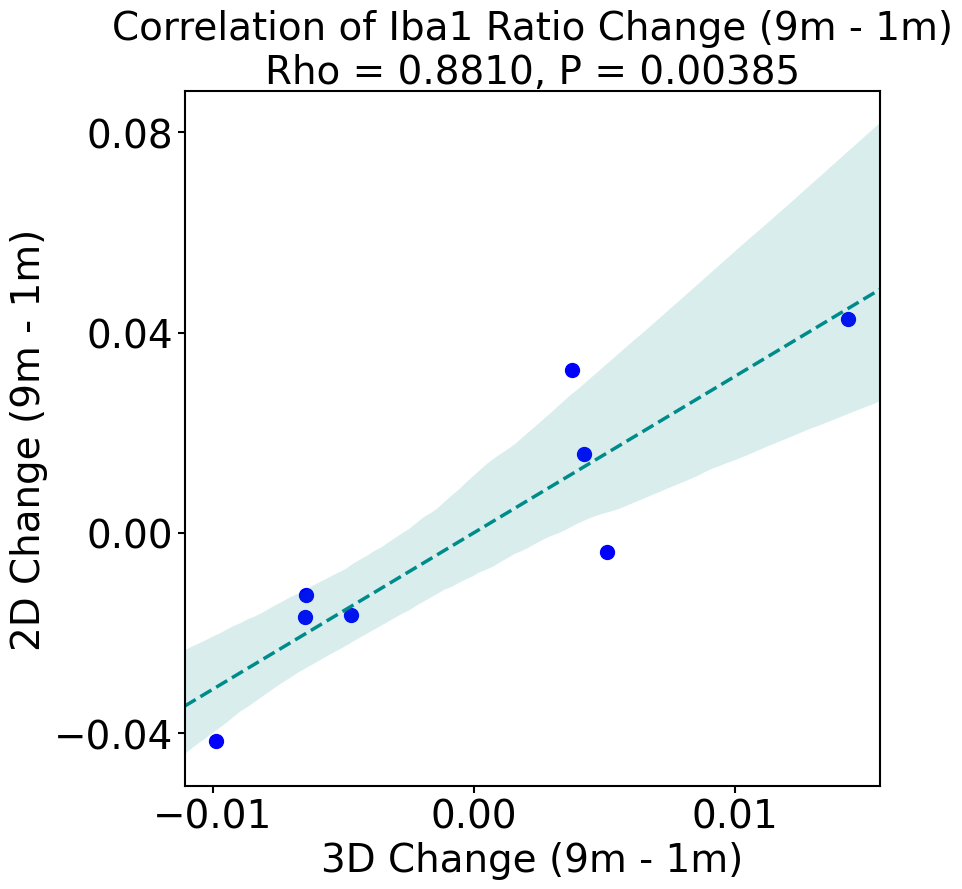

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr # Spearman 
import matplotlib.colors as mcolors
import os
import sys
import matplotlib #    

# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---

#
REFERENCE_3D_CSV_PATH = "/data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw/output_stardist/Iba1_Ratio_Pivot_WT_1m_vs_9m.csv"

#
BASE_STARDIST_DIR = "/data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw/output_stardist"
SLICE_THICKNESS_UM = 12.0
SAMPLES_TO_PROCESS = [
    ("WT_1m_Iba1_Hippocampus", "WT_1m"),
    ("WT_9m_Iba1_Hippocampus", "WT_9m")
]
COLUMN_ORDER_2D = ["WT_1m", "WT_9m"]

#
OUTPUT_DIR = "/data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/2D_Physical_slice_analysis/"
OUTPUT_PDF_PATH = os.path.join(OUTPUT_DIR, "Iba1_Ratio_Correlation_2D_vs_3D_Difference_9m_minus_1m.pdf")


# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---
#
def load_and_aggregate_slice_data(samples_info):
    """
     CSV 
     
    """
    all_samples_data = []
    
    for sample_name, condition in samples_info:
        print(f"--- 2D : {sample_name} (Condition: {condition}) ---")
        
        results_dir = os.path.join(BASE_STARDIST_DIR, sample_name, "region_aggregation_results")
        area_csv_path = os.path.join(results_dir, "region_areas_um2_pGM_pWM.csv")
        count_csv_path = os.path.join(results_dir, "iba1_positive_cell_counts_nonAF_pGM_pWM.csv")

        if not (os.path.exists(area_csv_path) and os.path.exists(count_csv_path)):
            print(f"  ->  : 2D CSV ")
            continue

        try:
            df_area = pd.read_csv(area_csv_path, index_col='slice_id')
            df_count = pd.read_csv(count_csv_path, index_col='slice_id')
            df_volume_um3 = df_area * SLICE_THICKNESS_UM

            total_counts_per_region = df_count.sum(axis=0)
            total_volume_um3_per_region = df_volume_um3.sum(axis=0)

            df_sample = pd.DataFrame({
                'Total_Iba1_Count': total_counts_per_region,
                'Total_Volume_um3': total_volume_um3_per_region
            }).reset_index()
            
            df_sample = df_sample.rename(columns={'index': 'atlasID'})
            df_sample['atlasID'] = df_sample['atlasID'].astype(int)
            df_sample['Sample'] = sample_name
            df_sample['Condition'] = condition
            
            all_samples_data.append(df_sample)
            print(f"  -> 2D : {len(df_area)}  ")

        except Exception as e:
            print(f"  ->  : {sample_name}  : {e}")

    if not all_samples_data:
        print(" :  2D 1 ")
        return pd.DataFrame()
        
    return pd.concat(all_samples_data, ignore_index=True)


# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---

print(f"===  1: 3D Pivot CSV  ===")
try:
    data_pivot_all_3d_raw = pd.read_csv(REFERENCE_3D_CSV_PATH, index_col='atlasID') / 1000
    data_pivot_3d = data_pivot_all_3d_raw[["WT_1m", "WT_9m"]]
    data_pivot_3d.columns = ["3D_1m", "3D_9m"]
    print(f"  -> 3D  (1m, 9m):\n{data_pivot_3d.head()}")
except FileNotFoundError:
    print(f"!!!  : 3D CSV : {REFERENCE_3D_CSV_PATH}")
    sys.exit(" ")
except Exception as e:
    print(f"!!!  : 3D CSV : {e}")
    sys.exit(" ")


print("\n===  2: 2D  ===")
all_data_2d = load_and_aggregate_slice_data(SAMPLES_TO_PROCESS)

if all_data_2d.empty:
    print("---  :  2D  ---")
    sys.exit(" ")

all_data_2d['Total_Iba1_per_Sample'] = all_data_2d.groupby('Sample')['Total_Iba1_Count'].transform('sum')
all_data_2d['Iba1_Ratio'] = all_data_2d['Total_Iba1_Count'] / all_data_2d['Total_Iba1_per_Sample']
all_data_2d['Iba1_Ratio'] = all_data_2d['Iba1_Ratio'].fillna(0)
data_pivot_2d = all_data_2d.pivot_table(
    index='atlasID', columns='Condition', values='Iba1_Ratio', aggfunc='mean'
).reindex(columns=COLUMN_ORDER_2D).fillna(0)
data_pivot_2d.columns = ["2D_1m", "2D_9m"]
print(f"  -> 2D :\n{data_pivot_2d.head()}")


print("\n===  3: 2D 3D atlasID  ===")
data_combined = pd.concat([data_pivot_2d, data_pivot_3d], axis=1)
data_combined = data_combined.fillna(0)
print(f"  -> 2D/3D  :\n{data_combined.head(8)}")


# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---

print("\n===  4:   (9m - 1m)   ===")
data_combined['2D_Diff'] = data_combined['2D_9m'] - data_combined['2D_1m']
data_combined['3D_Diff'] = data_combined['3D_9m'] - data_combined['3D_1m']
print(f"  ->  :\n{data_combined[['2D_Diff', '3D_Diff']].head(8)}")


print("\n===  5:  Spearman  ===")
try:
    corr, pval = spearmanr(data_combined['2D_Diff'], data_combined['3D_Diff'], nan_policy='omit')
except ValueError:
    print("  ->  :   ( ) Corr=0, Pval=1  ")
    corr, pval = 0.0, 1.0
    
print(f"  ->   (2D_Diff vs 3D_Diff): Rho = {corr:.4f}, P-value = {pval:.4g}")


# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---

print("\n===  6:   ( ) ===")

#
plt.style.use('default')
matplotlib.rcParams['pdf.use14corefonts'] = True
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.5

#
fig, ax = plt.subplots(figsize=(9, 9))

sns.regplot(
    ax=ax, #   ax  
    data=data_combined,
    x='3D_Diff', # X : 3D 
    y='2D_Diff', # Y : 2D 
    scatter_kws={'s': 100, 'alpha': 1, 'color': 'blue'}, #    
    line_kws={'color': 'darkcyan', 'linestyle': '--', 'linewidth': 2.5} #    
)

#
ax.set_title(f"Correlation of Iba1 Ratio Change (9m - 1m)\nRho = {corr:.4f}, P = {pval:.4g}", fontsize=28)
ax.set_xlabel("3D Change (9m - 1m)", fontsize=28)
ax.set_ylabel("2D Change (9m - 1m)", fontsize=28)

#
ax.tick_params(axis='both', which='major', labelsize=28)
ax.tick_params(direction='out', width=1.5, length=5)

#
#
ax.set_yticks([-0.04, 0, 0.04, 0.08])
# ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★


#
# ax.grid(True, linestyle='--', alpha=0.6) 

#
plt.tight_layout() 

#
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"  ->  : {OUTPUT_DIR}")

#
plt.savefig(OUTPUT_PDF_PATH, transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)

print(f"\n   :\n {OUTPUT_PDF_PATH}")

plt.show()

## ED31c - Recovery vs number of subsampled sections (100 trials/step)

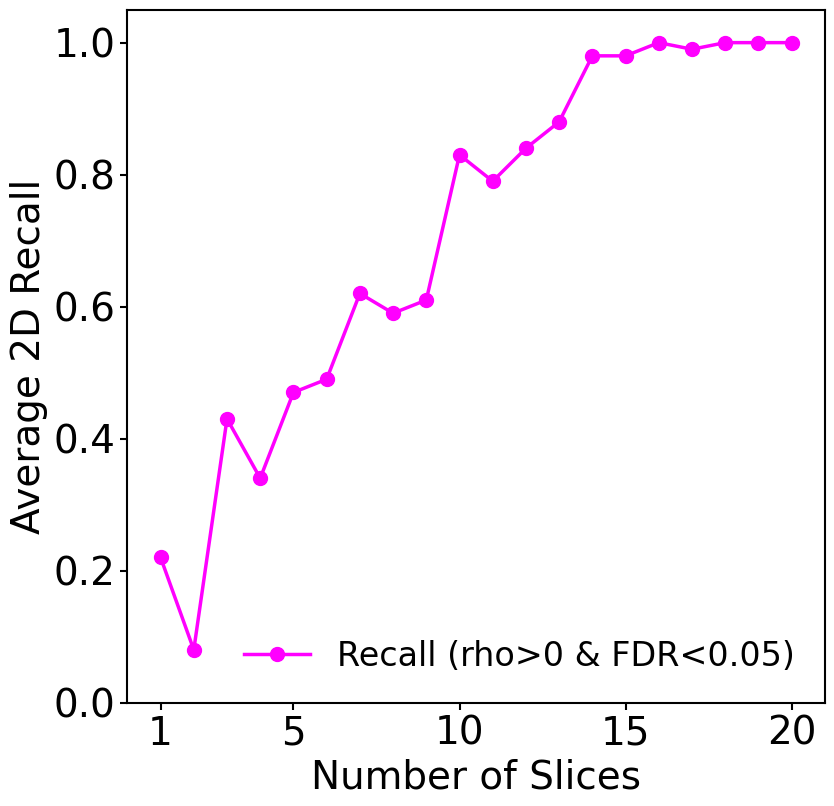

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import spearmanr #   Spearman 
import sys
#
from statsmodels.stats.multitest import fdrcorrection
import matplotlib #    

# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---

#
BASE_STARDIST_DIR = "/data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw/output_stardist"

#
INPUT_CSV_1M = os.path.join(BASE_STARDIST_DIR, "Iba1_Ratio_Simulation_WT_1m.csv")
INPUT_CSV_9M = os.path.join(BASE_STARDIST_DIR, "Iba1_Ratio_Simulation_WT_9m.csv")

#
REFERENCE_3D_CSV_PATH = "/data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw/output_stardist/Iba1_Ratio_Pivot_WT_1m_vs_9m.csv"

#
OUTPUT_PDF_PATH = os.path.join("/data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/2D_Physical_slice_analysis/", "Iba1_Ratio_Diff_Simulation_Recall_Ratio_Plot.pdf")

#
MAX_SLICES_TO_SIMULATE = 20
NUM_TRIALS = 100

#
FDR_ALPHA = 0.05

# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---

print("===  1: 3D ( )  ===")
try:
    #
    data_pivot_all_3d_raw = pd.read_csv(REFERENCE_3D_CSV_PATH, index_col='atlasID')
    data_pivot_3d = data_pivot_all_3d_raw[["WT_1m", "WT_9m"]] / 1000
    df_3d_diff = (data_pivot_3d['WT_9m'] - data_pivot_3d['WT_1m']).fillna(0)
    print("  -> 3D  (9m - 1m)  ")
except FileNotFoundError:
    print(f"!!!  : 3D CSV : {REFERENCE_3D_CSV_PATH}")
    sys.exit(" ")
except Exception as e:
    print(f"!!!  : 3D CSV : {e}")
    sys.exit(" ")


print("\n===  2:  CSV  ===")
try:
    df_sim_1m = pd.read_csv(INPUT_CSV_1M)
    df_sim_9m = pd.read_csv(INPUT_CSV_9M)
    print(f"  -> {INPUT_CSV_1M}  ")
    print(f"  -> {INPUT_CSV_9M}  ")
except FileNotFoundError:
    print(f"!!!  :  CSV ")
    sys.exit(" ")
except Exception as e:
    print(f"!!!  : CSV : {e}")
    sys.exit(" ")


# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---

print("\n===  3: 2D  (9m - 1m)   ===")
try:
    df_sim_1m = df_sim_1m.set_index(['k_slices', 'trial_num', 'atlasID'])['Iba1_Ratio']
    df_sim_9m = df_sim_9m.set_index(['k_slices', 'trial_num', 'atlasID'])['Iba1_Ratio']
    df_sim_diff = (df_sim_9m - df_sim_1m).fillna(0)
    print("  -> 2D ")
except KeyError:
    print("!!!  : CSV  (k_slices, trial_num, atlasID)  ")
    sys.exit(" ")
except Exception as e:
    print(f"!!!  : 2D : {e}")
    sys.exit(" ")


# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---

print("\n===  4: k trial Spearman  ===")
correlation_results = []
for k in range(1, MAX_SLICES_TO_SIMULATE + 1):
    for trial in range(1, NUM_TRIALS + 1):
        try:
            ratios_2d_diff = df_sim_diff.loc[(k, trial)]
            s_2d, s_3d = ratios_2d_diff.align(df_3d_diff, join='inner')
            
            if s_2d.empty or s_3d.empty or s_2d.std() == 0 or s_3d.std() == 0:
                corr = 0.0
                pval = 1.0
            else:
                corr, pval = spearmanr(s_2d, s_3d, nan_policy='omit')
            
            correlation_results.append({
                'k_slices': k,
                'trial_num': trial,
                'rho': corr,
                'p_value': pval
            })
        except KeyError:
            pass # k, trial  
        except ValueError:
             correlation_results.append({
                'k_slices': k, 'trial_num': trial, 'rho': 0.0, 'p_value': 1.0
            })
    if k % 5 == 0:
        print(f"    -> k = {k} ( {NUM_TRIALS}  )  ")

if not correlation_results:
    print("!!!  :  1 ")
    sys.exit(" ")

#
df_corr_results = pd.DataFrame(correlation_results)


# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---

print("\n===  5: k BH (FDR) Recall  ===")

recall_results = []

#
for k in range(1, MAX_SLICES_TO_SIMULATE + 1):
    
    #
    df_k = df_corr_results[df_corr_results['k_slices'] == k].copy()
    
    if df_k.empty:
        print(f"  ->  : k={k}  Recall=0  ")
        recall_results.append({'k_slices': k, 'recall_count': 0, 'recall_ratio': 0.0})
        continue

    #
    p_values_k = df_k['p_value']
    rejected, q_values = fdrcorrection(p_values_k, alpha=FDR_ALPHA, method='indep')
    df_k['fdr_q_value'] = q_values
    
    #
    significant_positive_trials = df_k[
        (df_k['rho'] > 0) & 
        (df_k['fdr_q_value'] < FDR_ALPHA)
    ]
    
    recall_count = len(significant_positive_trials)
    
    #
    recall_ratio = recall_count / NUM_TRIALS
    
    #
    recall_results.append({
        'k_slices': k,
        'recall_count': recall_count,
        'recall_ratio': recall_ratio  #   Ratio  
    })

#
df_recall = pd.DataFrame(recall_results)
print("  -> k Recall (Ratio):\n", df_recall[['k_slices', 'recall_ratio']])

# --- --- --- --- --- --- --- --- --- ---
#
# --- --- --- --- --- --- --- --- --- ---

print("\n===  6: Recall  ===")

#
plt.style.use('default')
matplotlib.rcParams['pdf.use14corefonts'] = True
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.5

fig, ax = plt.subplots(figsize=(9, 9))

#
ax.plot(df_recall['k_slices'], df_recall['recall_ratio'],
        marker='o', markersize=10, linestyle='-', linewidth=2.5,
        color='magenta', #  
        label=f'Recall (rho>0 & FDR<{FDR_ALPHA})')

#
ax.set_xlabel('Number of Slices', fontsize=28)
ax.set_ylabel('Average 2D Recall', fontsize=28) #   Y 

#
#
ax.set_xticks([1, 5, 10, 15, 20]) #    
# ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

ax.set_ylim(0, 1.05) #   Y 
ax.tick_params(axis='both', which='major', labelsize=28)
ax.tick_params(direction='out', width=1.5, length=5)

#
ax.legend(loc='lower right', fontsize=24, frameon=False) #    

#
ax.set_xlim(0, MAX_SLICES_TO_SIMULATE + 1)
#

#
output_dir = os.path.dirname(OUTPUT_PDF_PATH)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"  ->  : {output_dir}")

#
plt.savefig(OUTPUT_PDF_PATH, transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)
print(f"\nGraph saved to: {OUTPUT_PDF_PATH}")
plt.show()